# Superstore Sales & Profitability: Exploratory Data Analysis

This project explores a **public Sample Superstore retail dataset available on Kaggle** to understand sales performance, profitability, customer behavior, and the relationship between discounts and business outcomes.

The dataset contains **9,994 transaction records and 21 original fields**, covering orders from 2014 through 2017.

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

**Focus:** business performance · time-series trends · profitability · customer segmentation · discount strategy

## 1. Data overview

The analysis begins with a quick quality check: shape, data types, missing values, date coverage, and descriptive statistics for the core numerical measures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df = pd.read_csv("../data/retail_superstore.csv", encoding="cp1252")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

print(f"Rows: {len(df):,}")
print("Original columns: 21")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

Rows: 9,994
Original columns: 21
Date range: 2014-01-03 to 2017-12-30
Unique customers: 793
Missing values: 0


In [2]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


The dataset has no missing values in its original fields. Sales are highly variable, and individual transactions can range from large losses to large gains, which makes profitability analysis more informative than sales alone.

## 2. Category performance

Sales and profit are aggregated by product category to separate **revenue scale** from **profitability**.

In [3]:
category = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

category.round(2)

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80


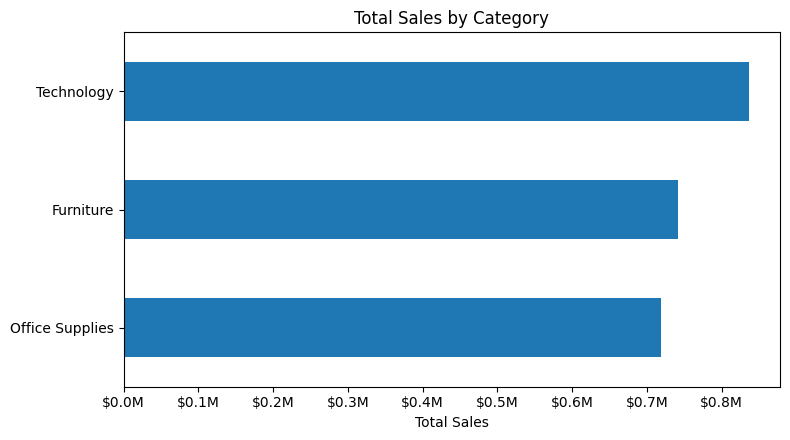

In [4]:
ax = category["Sales"].sort_values().plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Total Sales by Category")
ax.set_xlabel("Total Sales")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
plt.tight_layout()
plt.show()

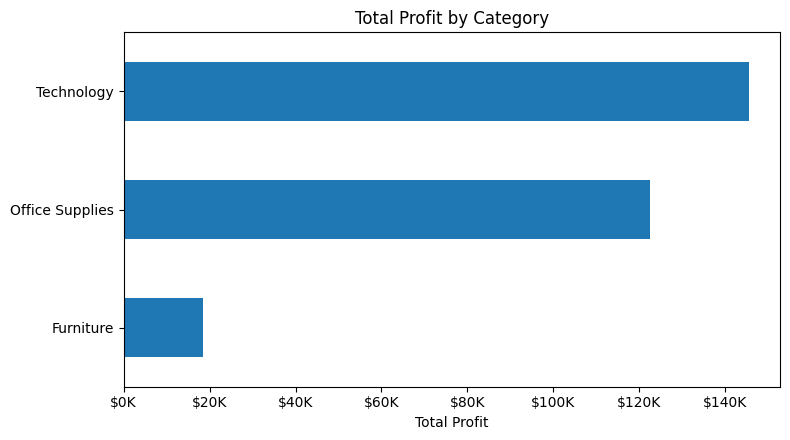

In [5]:
ax = category["Profit"].sort_values().plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Total Profit by Category")
ax.set_xlabel("Total Profit")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

**Technology** leads both total sales and total profit. **Furniture** generates substantial sales but far less profit than the other two categories, suggesting that revenue volume alone does not guarantee strong margins.

## 3. Regional performance

Regional aggregation shows whether the lowest-sales market is also the least profitable market.

In [6]:
region = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

region.round(2)

,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
Central,501239.89,39706.36
South,391721.90,46749.43


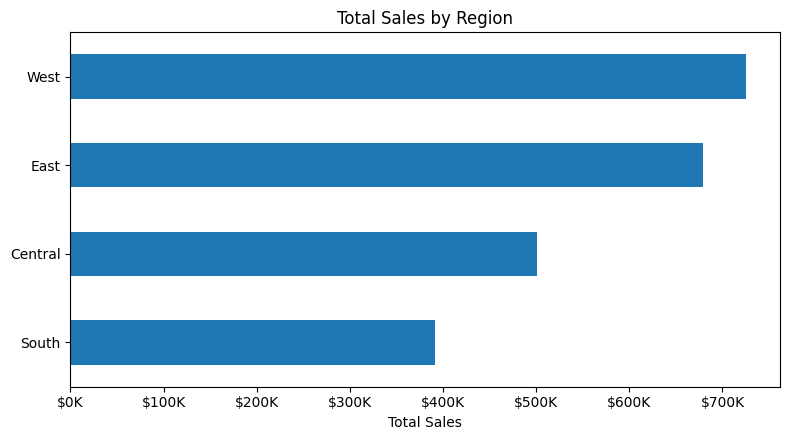

In [7]:
ax = region["Sales"].sort_values().plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Total Sales by Region")
ax.set_xlabel("Total Sales")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

The **West** produces the highest total sales. The **South** has the lowest sales, while the **Central** region has the lowest total profit. This distinction reinforces the need to evaluate both revenue and profitability.

## 4. Sales and profit trends over time

Monthly aggregation highlights seasonality and longer-term growth patterns.

In [8]:
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))[["Sales", "Profit"]]
      .sum()
      .reset_index()
)

monthly["Order Date"] = monthly["Order Date"].dt.to_timestamp()

annual = df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]].sum()
annual.round(2)

,Sales,Profit
Order Date,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


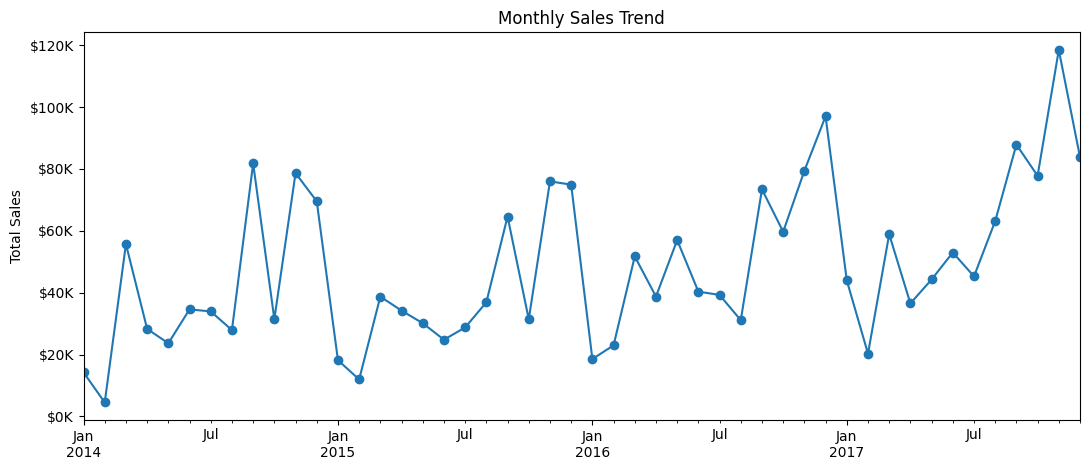

In [9]:
ax = monthly.plot(
    x="Order Date",
    y="Sales",
    figsize=(11, 4.8),
    marker="o",
    legend=False
)
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("")
ax.set_ylabel("Total Sales")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

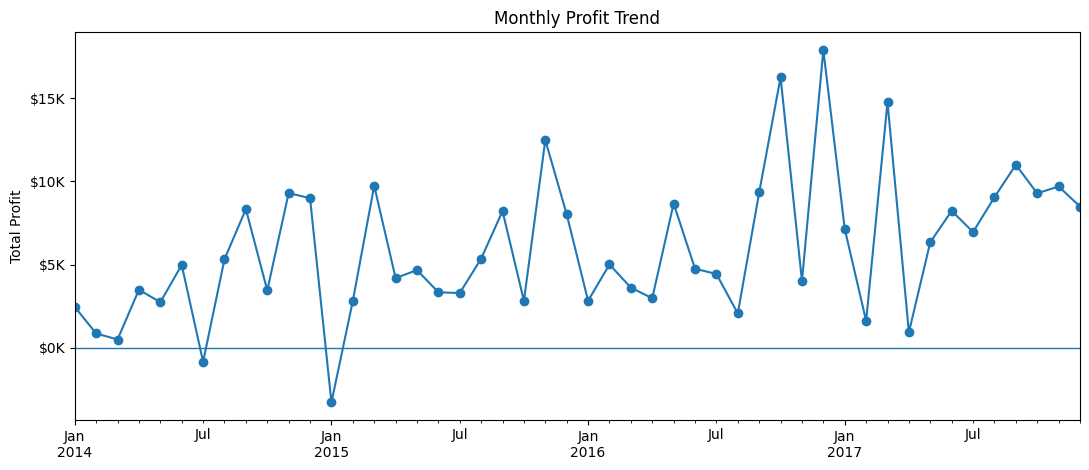

In [10]:
ax = monthly.plot(
    x="Order Date",
    y="Profit",
    figsize=(11, 4.8),
    marker="o",
    legend=False
)
ax.set_title("Monthly Profit Trend")
ax.set_xlabel("")
ax.set_ylabel("Total Profit")
ax.axhline(0, linewidth=1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

Annual sales rise from roughly **$484K in 2014 to $733K in 2017**, while annual profit increases from about **$49.5K to $93.4K**. Monthly results are volatile, with especially strong sales periods late in the year and occasional negative-profit months.

## 5. Relationships among sales, quantity, discount, and profit

A correlation matrix provides a compact view of linear relationships among the main numerical variables.

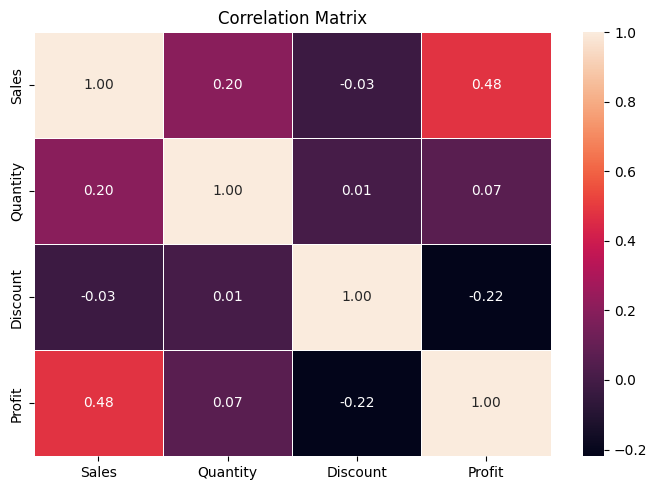

,Sales,Quantity,Discount,Profit
Sales,1.000,0.201,-0.028,0.479
Quantity,0.201,1.000,0.009,0.066
Discount,-0.028,0.009,1.000,-0.219
Profit,0.479,0.066,-0.219,1.000


In [11]:
corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr.round(3)

Sales and profit have a moderate positive correlation (**0.48**). Discount and profit are negatively correlated (**-0.22**), while discount and sales are close to uncorrelated (**-0.03**). This suggests that heavier discounting is not clearly associated with higher transaction sales, but it is associated with weaker profit.

## 6. Sub-category performance

Looking below the category level reveals products that generate high revenue but weak or negative profit.

In [12]:
subcategory = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

top_sales = subcategory.nlargest(5, "Sales")
top_profit = subcategory.nlargest(5, "Profit")
bottom_profit = subcategory.nsmallest(5, "Profit")

print("Top 5 by sales")
display(top_sales.round(2))

print("\nTop 5 by profit")
display(top_profit.round(2))

print("\nBottom 5 by profit")
display(bottom_profit.round(2))

Top 5 by sales


,Sales,Profit
Sub-Category,,
Phones,330007.05,44515.73
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Tables,206965.53,-17725.48
Binders,203412.73,30221.76



Top 5 by profit


,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76



Bottom 5 by profit


,Sales,Profit
Sub-Category,,
Tables,206965.53,-17725.48
Bookcases,114880.00,-3472.56
Supplies,46673.54,-1189.10
Fasteners,3024.28,949.52
Machines,189238.63,3384.76


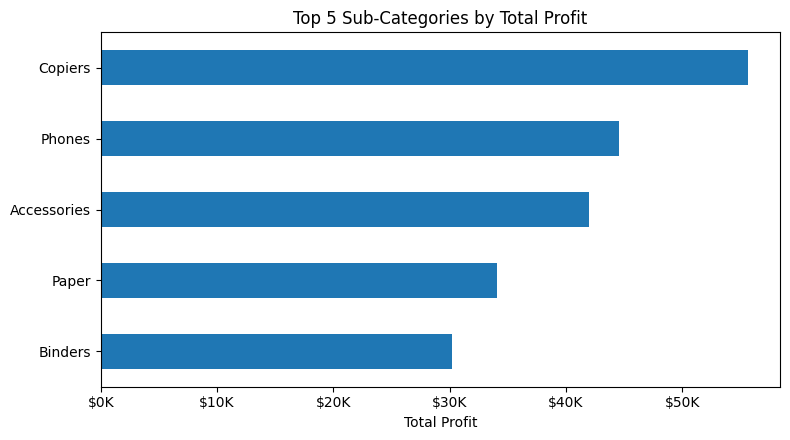

In [13]:
ax = top_profit["Profit"].sort_values().plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Top 5 Sub-Categories by Total Profit")
ax.set_xlabel("Total Profit")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

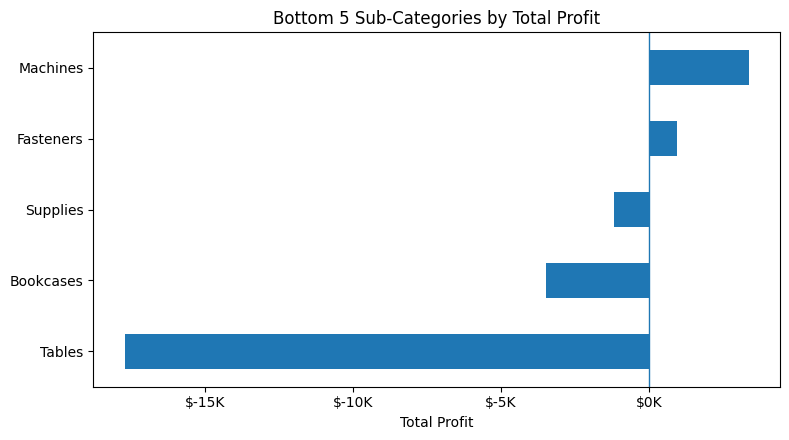

In [14]:
ax = bottom_profit["Profit"].sort_values().plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Bottom 5 Sub-Categories by Total Profit")
ax.set_xlabel("Total Profit")
ax.set_ylabel("")
ax.axvline(0, linewidth=1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
plt.tight_layout()
plt.show()

**Phones** perform strongly in both sales and profit, while **Copiers** produce the highest total profit. **Tables** are especially important to flag: they rank among the top sub-categories by sales but generate the largest total loss. This is a clear example of why high revenue should not be treated as a proxy for profitability.

## 7. Shipping mode and customer segment

Average sales and profit are compared across shipping choices and customer segments.

In [15]:
shipping = df.groupby("Ship Mode")[["Sales", "Profit"]].mean()
segment = df.groupby("Segment")[["Sales", "Profit"]].mean()

print("Average by shipping mode")
display(shipping.round(2))

print("\nAverage by customer segment")
display(segment.round(2))

Average by shipping mode


,Sales,Profit
Ship Mode,,
First Class,228.50,31.84
Same Day,236.40,29.27
Second Class,236.09,29.54
Standard Class,227.58,27.49



Average by customer segment


,Sales,Profit
Segment,,
Consumer,223.73,25.84
Corporate,233.82,30.46
Home Office,240.97,33.82


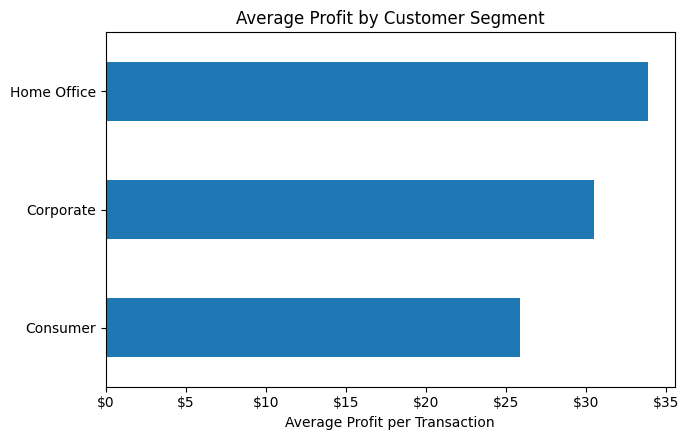

In [16]:
ax = segment["Profit"].sort_values().plot(kind="barh", figsize=(7, 4.5))
ax.set_title("Average Profit by Customer Segment")
ax.set_xlabel("Average Profit per Transaction")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}"))
plt.tight_layout()
plt.show()

Shipping-mode averages are fairly close, suggesting that shipping choice is not a major differentiator in average transaction value. **Home Office** has the highest average sales and average profit among the three customer segments.

## 8. Discount impact

To examine discounting at the daily business level, transactions are aggregated by order date using **average daily discount**, **total daily sales**, and **total daily profit**.

In [17]:
daily = (
    df.groupby("Order Date")
      .agg(
          Discount=("Discount", "mean"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

daily_corr = daily[["Discount", "Sales", "Profit"]].corr()
daily_corr.round(4)

,Discount,Sales,Profit
Discount,1.0000,-0.0447,-0.2284
Sales,-0.0447,1.0000,0.4891
Profit,-0.2284,0.4891,1.0000


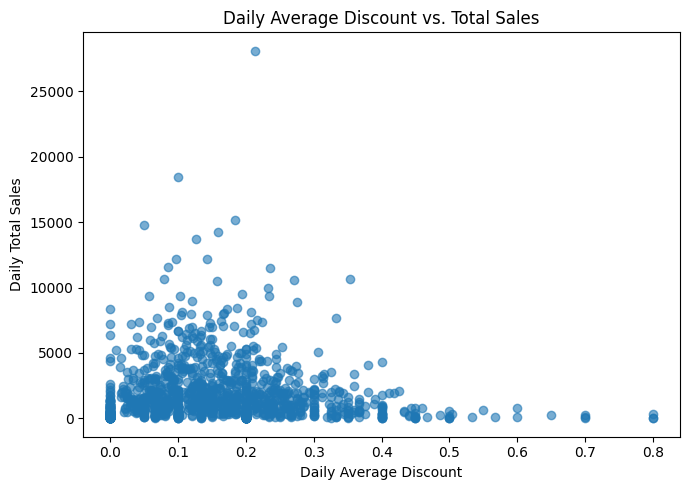

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(daily["Discount"], daily["Sales"], alpha=0.6)
plt.title("Daily Average Discount vs. Total Sales")
plt.xlabel("Daily Average Discount")
plt.ylabel("Daily Total Sales")
plt.tight_layout()
plt.show()

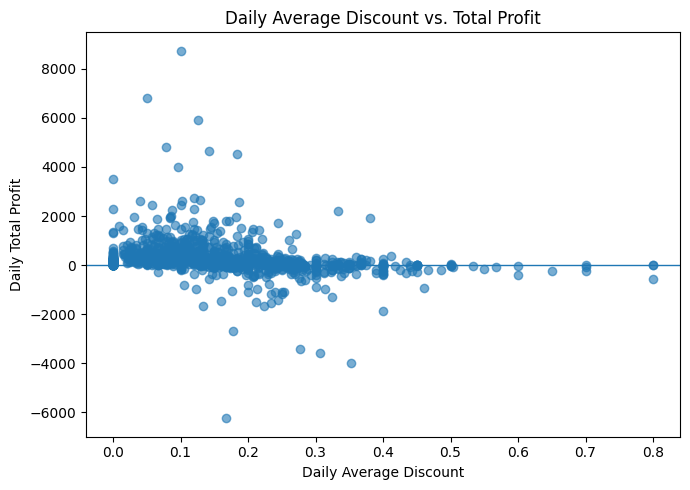

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(daily["Discount"], daily["Profit"], alpha=0.6)
plt.axhline(0, linewidth=1)
plt.title("Daily Average Discount vs. Total Profit")
plt.xlabel("Daily Average Discount")
plt.ylabel("Daily Total Profit")
plt.tight_layout()
plt.show()

Daily average discount has almost no linear relationship with daily sales (**r ≈ -0.04**), but it has a clearer negative relationship with daily profit (**r ≈ -0.23**). In this dataset, higher-discount days do not systematically generate higher sales and are more often associated with weaker profitability.

## 9. Business takeaways

- **Technology** is the strongest category on both sales and profit.
- **Furniture** deserves closer margin review because high revenue translates into relatively weak category profit.
- **Tables** are a notable risk: strong sales coexist with the largest sub-category loss.
- **Home Office** customers show the highest average sales and profit per transaction.
- Broad discounting is not supported by the observed relationship with sales and appears more closely associated with lower profit.
- A more selective promotion strategy—targeting specific products, customer groups, or inventory goals—would be more defensible than relying on heavy store-wide discounts.

These findings are descriptive and reflect patterns in this sample retail dataset rather than causal effects.